In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image
import zipfile

TRAIN_AND_OVERWRITE = False
MODELS_DIR = Path("local_models/vgg_classfier")
DATA_DIR = Path("data/EuroSAT_RGB")
ZIP_PATH = Path("data_zip/EuroSAT_RGB.zip")

def ensure_data():
    if DATA_DIR.exists() and any(DATA_DIR.iterdir()):
        return
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR.parent)
    print(f"Extracted {ZIP_PATH} -> {DATA_DIR.parent}")

ensure_data()

CATEGORIES = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
print("Categories:", CATEGORIES)

Extracted data_zip/EuroSAT_RGB.zip -> data
Categories: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
def load_category(category: str) -> np.ndarray:
    folder = DATA_DIR / category
    images = sorted(folder.glob("*.jpg"))
    arr = np.stack([
        np.array(Image.open(p).convert("RGB").resize((64, 64)))
        for p in images
    ])  # shape: (n_images, 64, 64, 3)
    return arr

data = {}
for cat in CATEGORIES:
    data[cat] = load_category(cat)
    print(f"{cat}: {data[cat].shape}, dtype={data[cat].dtype}")

AnnualCrop: (3000, 64, 64, 3), dtype=uint8
Forest: (3000, 64, 64, 3), dtype=uint8
HerbaceousVegetation: (3000, 64, 64, 3), dtype=uint8
Highway: (2500, 64, 64, 3), dtype=uint8
Industrial: (2500, 64, 64, 3), dtype=uint8
Pasture: (2000, 64, 64, 3), dtype=uint8
PermanentCrop: (2500, 64, 64, 3), dtype=uint8
Residential: (3000, 64, 64, 3), dtype=uint8
River: (2500, 64, 64, 3), dtype=uint8
SeaLake: (3000, 64, 64, 3), dtype=uint8


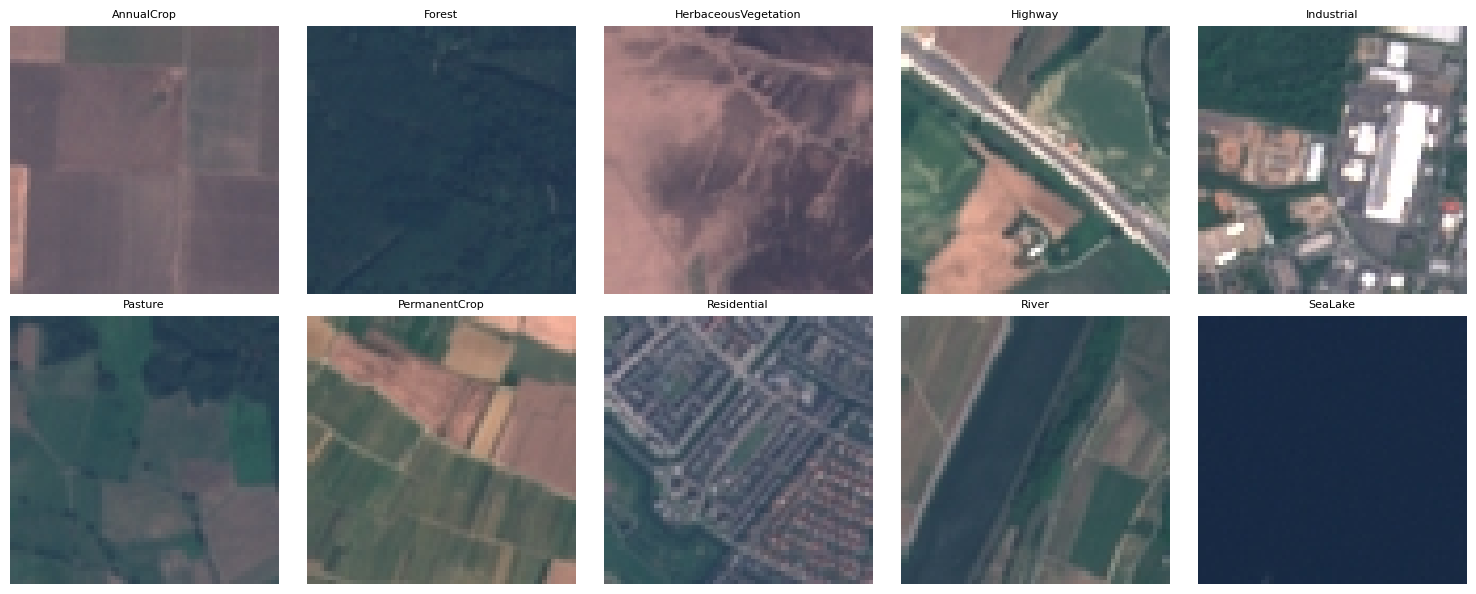

In [3]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(data[CATEGORIES[i]][0])
    ax.set_title(CATEGORIES[i], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Train test split

In [4]:
from sklearn.model_selection import train_test_split

split = 0.2

X = np.concatenate([data[cat] for cat in CATEGORIES], axis=0)
y = np.concatenate([np.full(data[cat].shape[0], i) for i, cat in enumerate(CATEGORIES)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (21600, 64, 64, 3), X_test: (5400, 64, 64, 3)
y_train: (21600,), y_test: (5400,)


In [5]:
import os
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1778886298.472531  129969 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
from keras.utils import to_categorical

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

### Model
Basic VGG style CNN. 3 convolutional blocks.

In [7]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_vgg_like_model() -> Sequential:
    
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
    model.add(Dense(10, activation='softmax'))

    return model

In [8]:
import json
from keras.models import load_model

def train_or_load_model(train_and_overwrite: bool) -> tuple[Sequential, dict]:
    MODELS_DIR.mkdir(exist_ok=True)
    model_path = MODELS_DIR / "vgg_like_model.keras"
    history_path = MODELS_DIR / "vgg_like_model_history.json"

    if train_and_overwrite:
        model = build_vgg_like_model()
        model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'], steps_per_execution=1)
        history_model = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

        model.save(model_path)
        with open(history_path, 'w') as f:
            json.dump(history_model.history, f)

        return model, history_model.history
    else:
        model = load_model(model_path)
        with open(history_path) as f:
            history = json.load(f)
        return model, history

In [9]:
model, history = train_or_load_model(TRAIN_AND_OVERWRITE)


I0000 00:00:1778886311.456503  129969 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2091 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
_, acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {acc}')

I0000 00:00:1778886314.932186  130172 service.cc:153] XLA service 0x76650c030640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778886314.932209  130172 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778886314.957176  130172 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778886315.027811  130172 cuda_dnn.cc:461] Loaded cuDNN version 92200


 39/169 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8978 - loss: 0.3348

I0000 00:00:1778886318.580495  130172 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8794 - loss: 0.3794
Test accuracy: 0.879444420337677


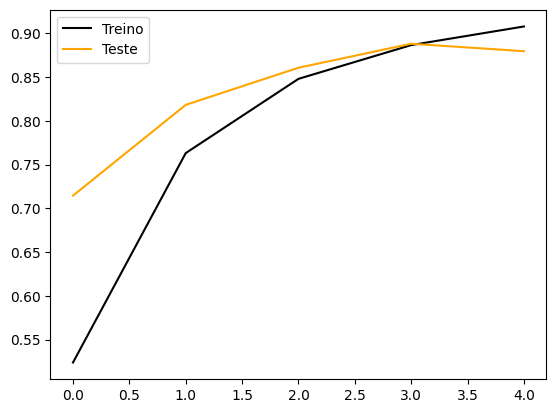

0.9076851606369019
0.879444420337677


In [11]:
# plt.title('Classification Accuracy')
plt.plot(history['accuracy'], color='black', label='Treino')
plt.plot(history['val_accuracy'], color='orange', label='Teste')
plt.legend(loc='best')
plt.show()

print(history['accuracy'][-1])
print(history['val_accuracy'][-1])

### Activation
Exploring activation maps on convolutional blocks

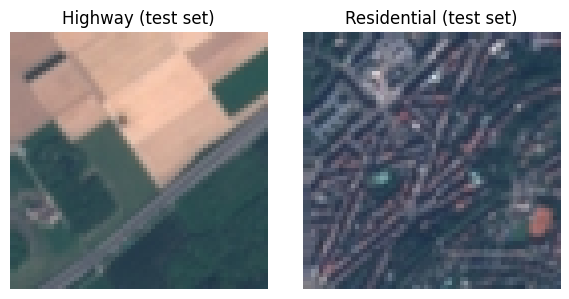


--- Highway ---
Category                  Probability
-------------------------------------
Highway                       1.0000 <-- predicted
River                         0.0000
AnnualCrop                    0.0000
PermanentCrop                 0.0000
HerbaceousVegetation          0.0000
Pasture                       0.0000
Industrial                    0.0000
SeaLake                       0.0000
Residential                   0.0000
Forest                        0.0000

--- Residential ---
Category                  Probability
-------------------------------------
Residential                   0.9988 <-- predicted
HerbaceousVegetation          0.0011
PermanentCrop                 0.0000
Industrial                    0.0000
Highway                       0.0000
River                         0.0000
Pasture                       0.0000
AnnualCrop                    0.0000
Forest                        0.0000
SeaLake                       0.0000


In [12]:
category_1 = "Highway"
category_2 = "Residential"

sample_1_idx = 100
# sample_1_idx = 90
sample_2_idx = 33

idx1 = np.where(y_test.argmax(axis=1) == CATEGORIES.index(category_1))[0][sample_1_idx]
idx2 = np.where(y_test.argmax(axis=1) == CATEGORIES.index(category_2))[0][sample_2_idx]
sample_1 = X_test[idx1]
sample_2 = X_test[idx2]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(sample_1)
axes[0].set_title(f"{category_1} (test set)")
axes[0].axis("off")
axes[1].imshow(sample_2)
axes[1].set_title(f"{category_2} (test set)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

for label, sample in [(category_1, sample_1), (category_2, sample_2)]:
    probs = model.predict(sample[np.newaxis], verbose=0)[0]
    print(f"\n--- {label} ---")
    print(f"{'Category':<25} {'Probability':>10}")
    print("-" * 37)
    for cat, p in sorted(zip(CATEGORIES, probs), key=lambda x: -x[1]):
        marker = " <-- predicted" if p == probs.max() else ""
        print(f"{cat:<25} {p:>10.4f}{marker}")

In [13]:
from keras import Input
from keras.models import Model

inp = Input(shape=(64, 64, 3))
x = inp
conv_outputs = []
for layer in model.layers:
    x = layer(x)
    if 'conv' in layer.name:
        conv_outputs.append(x)

activation_model = Model(inputs=inp, outputs=conv_outputs)

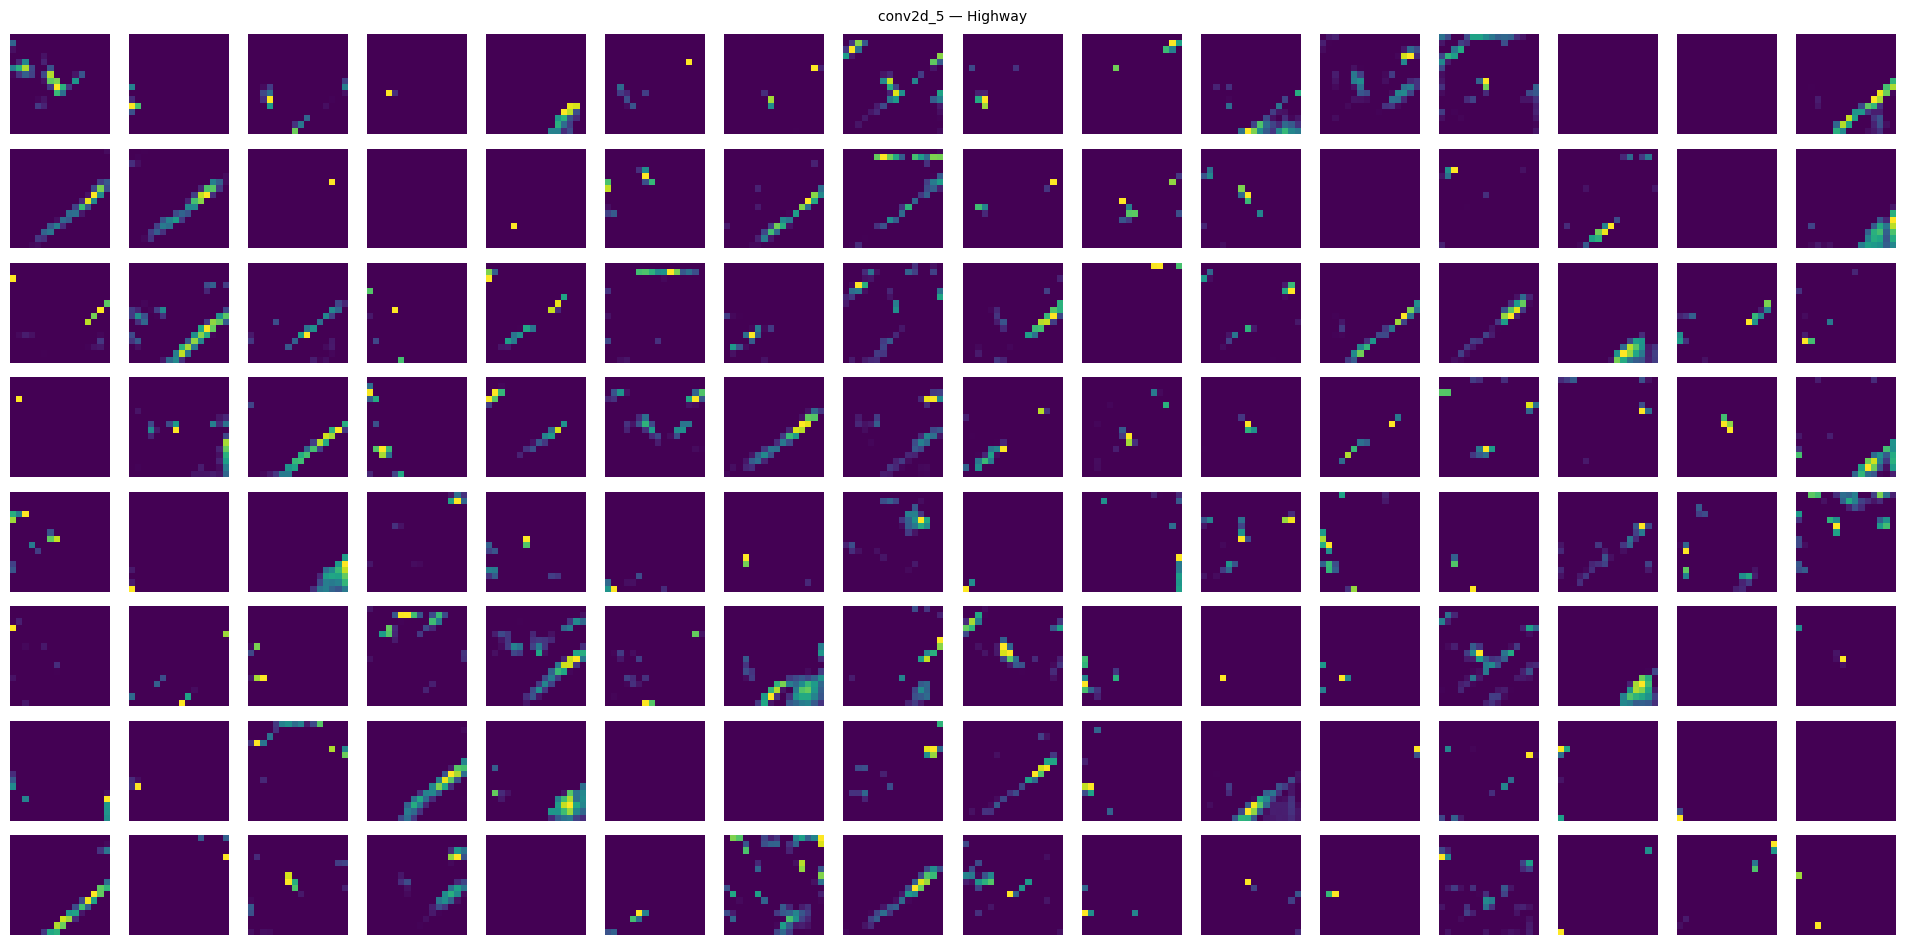

In [14]:
acts_1 = activation_model.predict(sample_1[np.newaxis], verbose=0)
act_1 = acts_1[-1][0]  # (8, 8, 128)

conv_name = [l.name for l in model.layers if 'conv' in l.name][-1]
cols, rows = 16, act_1.shape[-1] // 16

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
fig.suptitle(f"{conv_name} — {category_1}", fontsize=10)
for i, ax in enumerate(axes.flat):
    ax.imshow(act_1[:, :, i], cmap='viridis')
    ax.axis('off')
plt.tight_layout()
plt.show()

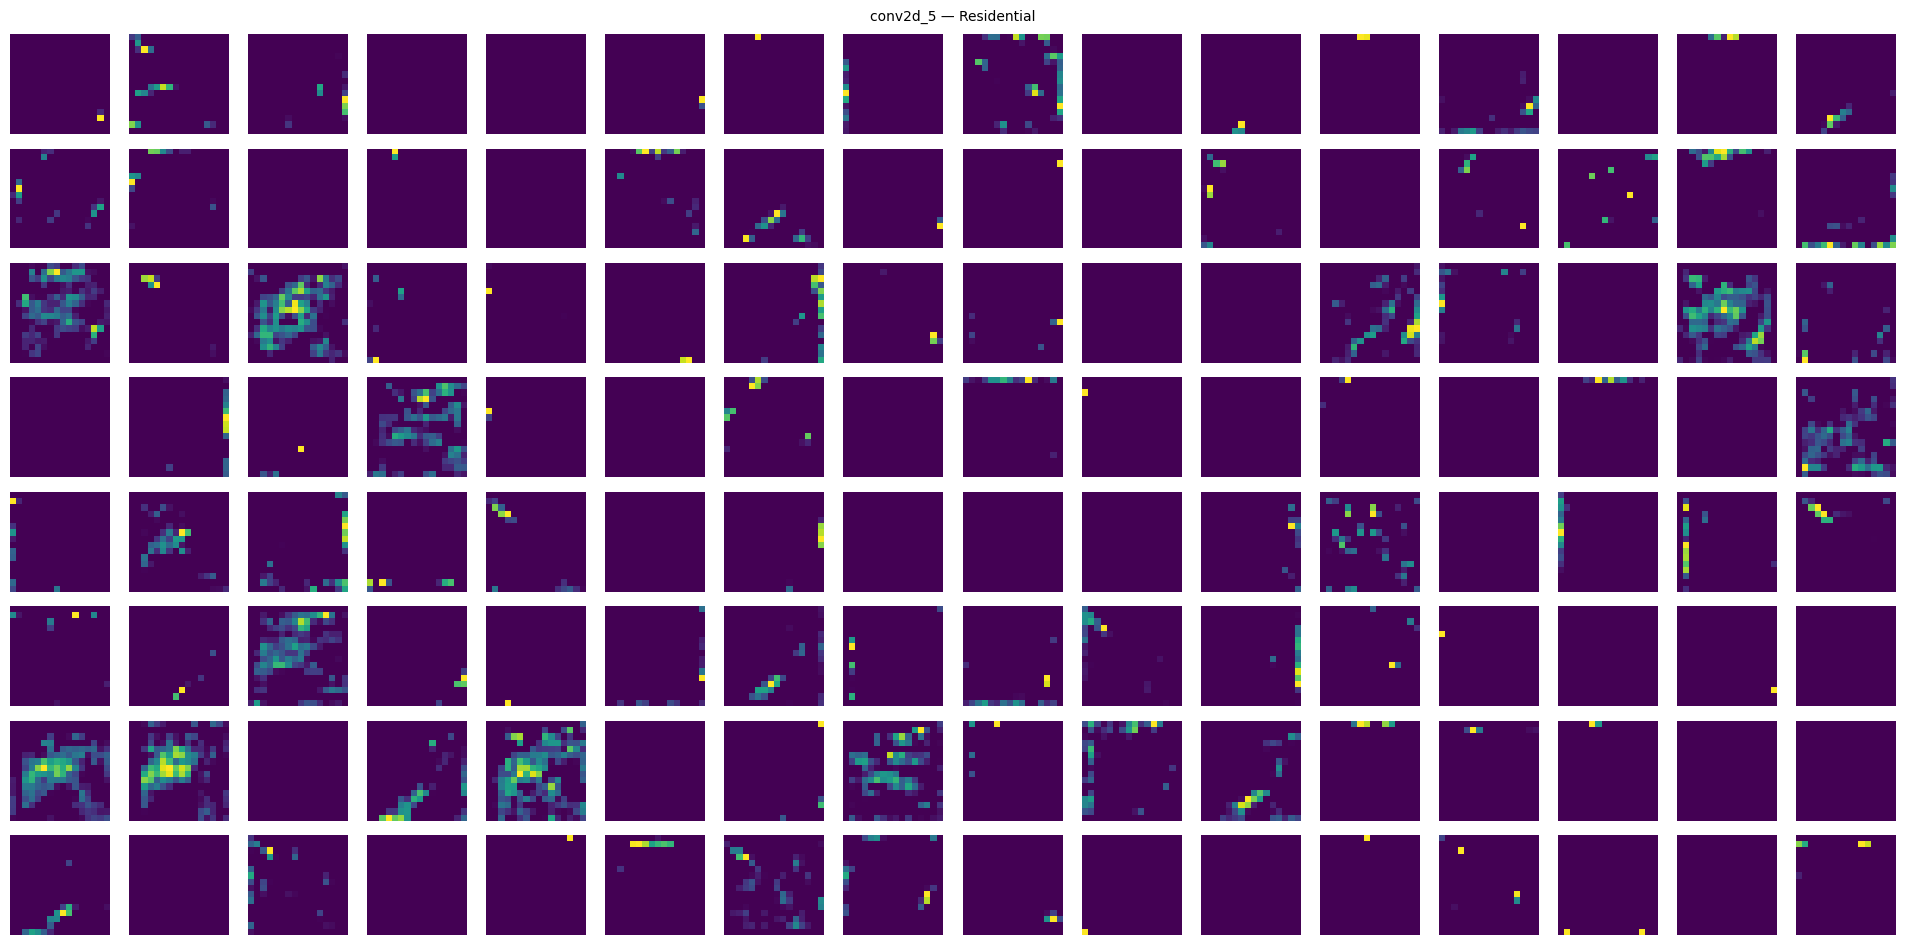

In [15]:
acts_2 = activation_model.predict(sample_2[np.newaxis], verbose=0)
act_2 = acts_2[-1][0]  # (8, 8, 128)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
fig.suptitle(f"{conv_name} — {category_2}", fontsize=10)
for i, ax in enumerate(axes.flat):
    ax.imshow(act_2[:, :, i], cmap='viridis')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
import tensorflow as tf
from keras import Input
from keras.models import Model

# model outputting [last conv activations, final predictions]
inp_g = Input(shape=(64, 64, 3))
x = inp_g
last_conv_out = None
for layer in model.layers:
    x = layer(x)
    if 'conv' in layer.name:
        last_conv_out = x  # updated each conv, ends on last
final_out = x

grad_model = Model(inputs=inp_g, outputs=[last_conv_out, final_out])

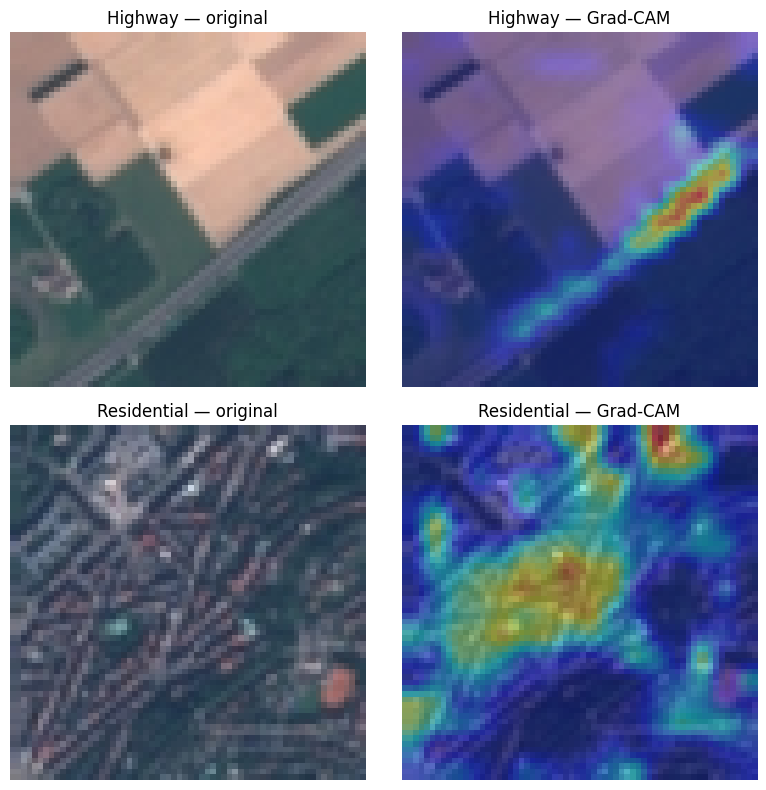

In [17]:
import cv2

def grad_cam(img, class_idx):
    img_tensor = tf.cast(img[np.newaxis], tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        tape.watch(conv_outputs)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)       # (1, H, W, K)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2)) # (K,) — α_k
    heatmap = conv_outputs[0] @ weights[..., tf.newaxis]  # (H, W, 1)
    heatmap = tf.nn.relu(tf.squeeze(heatmap)).numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap

def overlay_grad_cam(img, heatmap, alpha=0.4):
    h = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    h = np.uint8(255 * h)
    h_color = cv2.applyColorMap(h, cv2.COLORMAP_JET)
    h_color = cv2.cvtColor(h_color, cv2.COLOR_BGR2RGB)
    return np.uint8(img * 255 * (1 - alpha) + h_color * alpha)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, (sample, label) in enumerate([(sample_1, category_1), (sample_2, category_2)]):
    class_idx = CATEGORIES.index(label)
    heatmap = grad_cam(sample, class_idx)
    overlaid = overlay_grad_cam(sample, heatmap)

    axes[row, 0].imshow(sample)
    axes[row, 0].set_title(f"{label} — original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(overlaid)
    axes[row, 1].set_title(f"{label} — Grad-CAM")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Predictions:
  River                     0.8044
  SeaLake                   0.1065
  AnnualCrop                0.0882
  Pasture                   0.0005
  Highway                   0.0003
  Forest                    0.0000
  HerbaceousVegetation      0.0000
  PermanentCrop             0.0000
  Industrial                0.0000
  Residential               0.0000


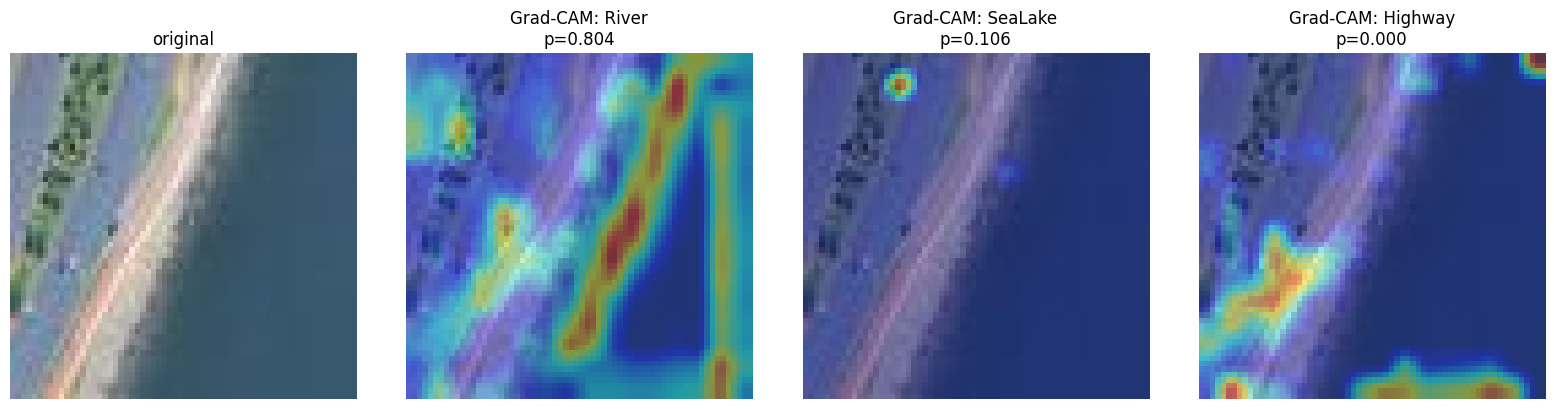

In [18]:
custom = np.array(Image.open("data/custom_samples/botafogo_64x64.jpg").convert("RGB")).astype("float32") / 255

probs = model.predict(custom[np.newaxis], verbose=0)[0]
print("Predictions:")
for cat, p in sorted(zip(CATEGORIES, probs), key=lambda x: -x[1]):
    print(f"  {cat:<25} {p:.4f}")

target_classes = ["River", "SeaLake", "Highway"]

fig, axes = plt.subplots(1, len(target_classes) + 1, figsize=(4 * (len(target_classes) + 1), 4))
axes[0].imshow(custom)
axes[0].set_title("original")
axes[0].axis("off")

for ax, label in zip(axes[1:], target_classes):
    heatmap = grad_cam(custom, CATEGORIES.index(label))
    overlaid = overlay_grad_cam(custom, heatmap)
    ax.imshow(overlaid)
    ax.set_title(f"Grad-CAM: {label}\np={probs[CATEGORIES.index(label)]:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()